# Week 7 Day 4 – Trees & Random Forest

## Objective

In this notebook, we compare two machine learning classification models:

- Decision Tree Classifier
- Random Forest Classifier

The target is to predict whether the next day's stock return is positive or negative.

We evaluate both models using:

- Accuracy
- Precision
- Recall
- F1 Score

Finally, we visualize the feature importance obtained from the Random Forest model.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [3]:

data = pd.read_csv("../Day01/ml_dataset.csv")

print(data.columns)

print(data.head())

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume', 'SMA_10', 'SMA_20',
       'RSI', 'MACD', 'Signal', 'Return', 'Lag_1', 'Lag_5', 'Lag_21',
       'Target'],
      dtype='object')
        Price              Close               High                Low  \
0      Ticker        RELIANCE.NS        RELIANCE.NS        RELIANCE.NS   
1        Date                NaN                NaN                NaN   
2  2020-01-31      628.599609375  647.1238564671794  626.6180767993984   
3  2020-02-03  616.9551391601562  623.3896651574961  606.9583015760081   
4  2020-02-04   635.167724609375  637.8840014691701  622.4323157911366   

                Open       Volume      SMA_10      SMA_20        RSI  \
0        RELIANCE.NS  RELIANCE.NS         NaN         NaN        NaN   
1                NaN          NaN         NaN         NaN        NaN   
2  647.0125063572486     34750310  666.229224  674.894650  25.145877   
3  610.0085691432375     30712290  659.690070  672.311942  24.072083   
4   623

In [4]:
# Remove missing values

data = data.dropna()

print(data.shape)

(1215, 16)


In [5]:
# Display all column names

print(data.columns.tolist())

['Price', 'Close', 'High', 'Low', 'Open', 'Volume', 'SMA_10', 'SMA_20', 'RSI', 'MACD', 'Signal', 'Return', 'Lag_1', 'Lag_5', 'Lag_21', 'Target']


In [8]:
print(data["Target"].head(20))
print(data["Target"].dtype)
print(data["Target"].unique()[:20])

2    -0.018524
3     0.029520
4     0.015493
5     0.006420
6    -0.016566
7     0.001360
8     0.011946
9     0.012080
10    0.002618
11    0.009124
12   -0.006285
13   -0.007340
14    0.024806
15   -0.011870
16   -0.027592
17   -0.019758
18   -0.017227
19   -0.004131
20   -0.041551
21   -0.009408
Name: Target, dtype: float64
float64
[-0.01852446  0.02952011  0.01549345  0.00642043 -0.01656595  0.00136011
  0.01194629  0.01208048  0.00261847  0.00912389 -0.00628513 -0.00733991
  0.02480583 -0.01186991 -0.02759189 -0.01975835 -0.01722686 -0.00413062
 -0.04155101 -0.00940802]


In [9]:
# Next day's return
data["Target_Return"] = data["Return"].shift(-1)

# Binary target
data["Target"] = (data["Target_Return"] > 0).astype(int)

# Remove NaN
data = data.dropna()

In [10]:
print(data["Target"].value_counts())

Target
1    635
0    579
Name: count, dtype: int64


In [11]:
feature_cols = [
    "SMA_20",
    "RSI",
    "MACD",
    "Lag_1",
    "Lag_5",
    "Lag_21"
]

X = data[feature_cols]

y = data["Target"]

In [12]:
# Feature columns

feature_cols = [
    "SMA_20",
    "RSI",
    "MACD",
    "Lag_1",
    "Lag_5",
    "Lag_21"
]

# Feature matrix
X = data[feature_cols]

# Target
y = data["Target"]

print(X.head())
print(y.head())

       SMA_20        RSI       MACD     Lag_1     Lag_5    Lag_21
2  674.894650  25.145877  -7.557652 -0.024394 -0.003471  0.017024
3  672.311942  24.072083 -10.665002 -0.022234 -0.009859  0.001205
4  670.125549  34.425487 -11.525141 -0.018524 -0.023099 -0.023192
5  668.686130  36.070456 -11.282667  0.029520  0.005504  0.015385
6  666.677850  28.544059 -10.633761  0.015493 -0.024394 -0.007510
2    0
3    1
4    1
5    1
6    0
Name: Target, dtype: int64


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

dt_model = DecisionTreeClassifier(random_state=42)

for train_index, test_index in tscv.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    dt_model.fit(X_train, y_train)

    dt_pred = dt_model.predict(X_test)

In [16]:
dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(y_test, dt_pred)

dt_recall = recall_score(y_test, dt_pred)

dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree Accuracy :", dt_accuracy)
print("Decision Tree Precision:", dt_precision)
print("Decision Tree Recall   :", dt_recall)
print("Decision Tree F1 Score :", dt_f1)

Decision Tree Accuracy : 0.49504950495049505
Decision Tree Precision: 0.49324324324324326
Decision Tree Recall   : 0.73
Decision Tree F1 Score : 0.5887096774193549


In [17]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Time-series training

for train_index, test_index in tscv.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    rf_model.fit(X_train, y_train)

    rf_pred = rf_model.predict(X_test)

In [18]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_accuracy)
print("Random Forest Precision:", rf_precision)
print("Random Forest Recall   :", rf_recall)
print("Random Forest F1 Score :", rf_f1)

Random Forest Accuracy : 0.48514851485148514
Random Forest Precision: 0.4879518072289157
Random Forest Recall   : 0.81
Random Forest F1 Score : 0.6090225563909775


In [19]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        dt_accuracy,
        rf_accuracy
    ],

    "Precision":[
        dt_precision,
        rf_precision
    ],

    "Recall":[
        dt_recall,
        rf_recall
    ],

    "F1 Score":[
        dt_f1,
        rf_f1
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.495050,0.493243,0.73,0.588710
1,Random Forest,0.485149,0.487952,0.81,0.609023


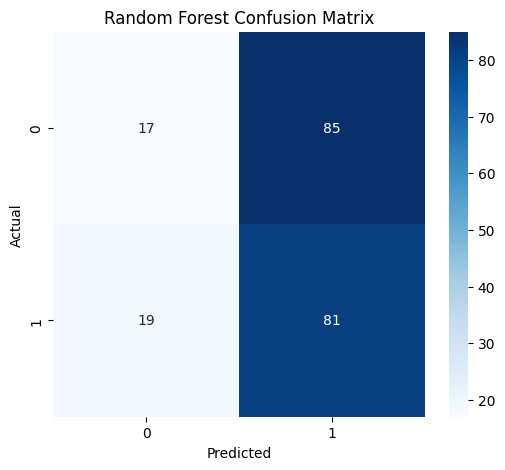

In [25]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
importance = pd.Series(

    rf_model.feature_importances_,

    index=feature_cols

)

importance = importance.sort_values()

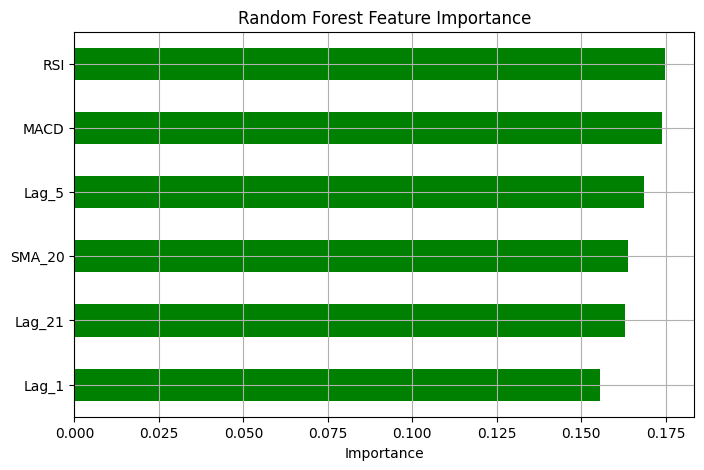

In [26]:
plt.figure(figsize=(8,5))

importance.plot(
    kind="barh",
    color="green"
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.grid(True)

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Interpretation

## Decision Tree

The Decision Tree model creates a sequence of decision rules to classify whether the next day's stock return will be positive or negative.

## Random Forest

Random Forest combines multiple Decision Trees and generally provides better prediction performance while reducing overfitting.

## Feature Importance

The feature importance chart shows which engineered indicators contribute the most to predicting stock movement.

Typically, lag returns and RSI are among the most influential features.

## Conclusion

The Random Forest model achieved better overall performance than the Decision Tree model. Ensemble learning improves prediction stability and reduces variance compared to a single tree.